$$ \textrm{Joaquín Peñuela-Parra} $$
$$ \textrm{Department of Mechanical Engineering and Materials Science} $$
$$ \textrm{University of Pittsburgh, Pittsburgh, Pennsylvania 15261, USA} $$ 

This is a tutorial file about how to work using exact diagonalization for simulating quantum systems. 

Exact diagonalization means doing all tensor products ($\otimes$). For example, if we have an operator $\sigma^{x}_{1}$ in a system of 4 sites, the global operator is $\sigma^{x} \otimes I \otimes I \otimes I$, the position in the tensor product indicates in which site is acting, any other site where the operator is not acting will have identities.

**Note:** Ordering is arbitrary, in principle you can say $\sigma^{x}_{1} = \sigma^{x} \otimes I \otimes I \otimes I$ or $\sigma^{x}_{1} =  I \otimes I \otimes I \otimes \sigma^{x}$, that is equivalent to think $|01 \rangle$ is $|0 \rangle \otimes |1 \rangle$ or $|1 \rangle \otimes |0 \rangle$. **The direction where you decide to add the "sites" and multiple the tensor product is a convention, you just need to be consistent.** We will use the one that consists on multiply the tensor products at the left, I do not like it but it is the most common, i.e. $\sigma^{x}_{1} =  I \otimes I \otimes I \otimes \sigma^{x}$.

Ok, let's start with spins.

For spins, the basis is $\{ | \uparrow \rangle , | \downarrow \rangle \}$. The vector representation is:

In [1]:
↑ = [1; 0]
↓ = [0; 1];

**1. Build the state $| \uparrow \downarrow \uparrow \downarrow \uparrow \downarrow \rangle$**

In [ ]:
kron(↓, ↑, ↓, ↑, ↓, ↑) #Note that it looks in reverse order due to the convention use here, we are multiplying tensor products at the left

The local operators $\sigma^{x}, \sigma^{y}, \sigma^{z}, \sigma^{+}, \sigma^{-}$ are given by:

In [2]:
σx = [0 1; 1 0]
σy = [0 -1im; 1im 0]
σz = [1 0; 0 -1]
Identity = [1 0; 0 1]
σplus = (σx +1im*σy)/2
σminus = adjoint(σplus);

Now, to build any operator you can use the following:

In [3]:
"""
Builds O_j as I⊗...⊗I⊗O⊗I...⊗I for a system of N sites.

Note: If the local representation is an sparse matrix, the output of this function will also be an sparse matrix. This is very important for larger N.

**Parameters:**
* `N (Int64):` System size.
* `j (Int64):` Site where the local operator O is acting.
* `matrix (Matrix{Any}):` Matrix representation for the local operator O. 

**Return:**
* `M (Matrix{Any}):` Global operator of O_j i.e. Tensor product I⊗...⊗I⊗O⊗I...⊗I.
"""
function Enlarge_Matrix_site_j(N::Int64, j::Int64, matrix)

    global Identity
    
    M = Identity
    j == 1 ? M = matrix : nothing
    
    for i=2:N 
        i == j ? M = kron(matrix, M) :  M = kron(Identity, M) 
    end

    return M
end

"""
Builds A_iB_j as I⊗...⊗I⊗B⊗I...⊗I⊗A⊗I⊗I...⊗I (for i<j) for a system of N sites.

Note: If the local representation are sparse matrices, the output of this function will also be an sparse matrix. This is very important for larger N.

**Parameters:**
* `N (Int64):` System size.
* `i (Int64):` Site where the local operator A is acting.
* `j (Int64):` Site where the local operator B is acting.
* `matrix_i (Int64):` Matrix representation for the local operator A.
* `matrix_j (Int64):` Matrix representation for the local operator B.

**Return:**
* `M (Matrix{Any}):` Global operator of A_iB_j i.e. Tensor product I⊗...⊗I⊗B⊗I...⊗I⊗A⊗I⊗I...⊗I (for i<j).
"""
function Enlarge_Matrix_i_Matrix_j(N::Int64, i::Int64, j::Int64, matrix_i, matrix_j)
    global Identity
    
    M = Identity

    j == 1 ? M = matrix_j : nothing
    i == 1 ? M = matrix_i : nothing
 
    for k=2:N 
        if k == j
            M = kron(matrix_j, M)
        elseif k == i
            M = kron(matrix_i, M)
        else
            M = kron(Identity, M)     
        end
    end

    return M
end

Enlarge_Matrix_i_Matrix_j

**2. Read the functions and understand what is happening. What would change if we decide to use the other convention, i.e. multiplying $\otimes$ at the right?**

**Answer:** __________

**3. Considering a system size of N = 6, build the following operators:**

$\sigma^{+}_{1}\sigma^{-}_{1}$, for this one also test that `Enlarge_Matrix_site_j(N::Int64, j::Int64, matrix)` is generating the right matrix, i.e. calculate it using the function but also writing the kronecker products.

In [ ]:
Enlarge_Matrix_site_j(6, 1, σplus*σminus)

$\sigma^{+}_{1}\sigma^{-}_{1}\sigma^{x}_{2}$

In [ ]:
#HINT: You can build each one apart and just multiply them.

$\sigma^{x}_{1}\sigma^{y}_{2} - \sigma^{x}_{2}\sigma^{y}_{1}$

In [ ]:
#HINT: You can build them apart and just do the substraction

$H = \sum_{n=1}^{N-1} J(\sigma^{x}_{n}\sigma^{x}_{n+1} + \sigma^{y}_{n}\sigma^{y}_{n+1}) +  \Delta \sigma^{z}_{n}\sigma^{z}_{n+1}$ with $J = 1$ y $\Delta = 2$

In [ ]:
H = 

**4. Diagonalyze the previous H and find the groundstate (eigenvector with smallest eigenvalue)**

In [ ]:
GS = 

**5. Using the groundstate calculate the expectation value of $\sigma^{z}_{i}$ for all sites**

Ok, that is enough for spins, now let's do something with Fermions, that is what we will be working. The mathematical details of these function is harder.

In [4]:
zero = [1; 0]
one = [0; 1];

"""
Builds the creation operator C†_j as an sparse matrix based on the Jordan-Wigner transformation C†_j = (∑_i<j σz_i) σ-_j.

**Parameters:**
* `N (Int64):` System size.
* `j (Int64):` Site where creation operator is acting.

**Return:**
* `Matrix (SparseMatrixCSC{ComplexF64, Int64}):` Matrix representation of C†_j.
"""
function Build_Cdag_Matrix(N::Int64, j::Int64)
    global σminus, σz, Identity

    if j == 1
        Matrix = σminus
    else
        Matrix = σz
    end

    for i=2:N 
        if i <= j-1
        Matrix = kron(σz, Matrix)
        elseif i == j
        Matrix = kron(σminus, Matrix)
        else
        Matrix = kron(Identity, Matrix)  
        end
    end 

    return Matrix

end

"""
Builds the annihilation operator C_j as an sparse matrix based on the Jordan-Wigner transformation C_j = (∑_i<j σz_i) σ+_j.

**Parameters:**
* `N (Int64):` System size.
* `j (Int64):` Site where annihilation operator is acting.

**Return:**
* `Matrix (SparseMatrixCSC{ComplexF64, Int64}):` Matrix representation of C_j.
"""
function Build_C_Matrix(N::Int64, j::Int64)
    global σplus, σz, Identity

    if j == 1
        Matrix = σplus
    else
        Matrix = σz
    end
    
    for i=2:N 
        if i <= j-1
        Matrix = kron(σz, Matrix)
        elseif i == j
        Matrix = kron(σplus, Matrix)
        else
        Matrix = kron(Identity, Matrix)
        end
    end 

    return Matrix

end

Build_C_Matrix

**6. Check that $c_{i}^{\dagger}c_{j} = - c_{j}c_{i}^{\dagger}$ if $i \neq j$**

**7. Create the state $| \Psi \rangle = | 01100 \rangle$, this will be used in questions 8, 9, and 10.**

**8. Using the previous state calculate the occupation in each site, i.e. the expectation value of $n_i = c^{\dagger}_{i}c_{i}$, it makes sense?**

**9. Apply $c^{\dagger}_{1}$ to $| \Psi \rangle$, is the state $|111000 \rangle$?**

**10. Apply $c^{\dagger}_{4}c_{2}$ to $| \Psi \rangle$, is the state $|00110 \rangle$? or there is a minus somewhere?**

**11. Create $H = \sum_{n=1}^{N-1} [ J(c^{\dagger}_{n+1}c_{n}  + c^{\dagger}_{n}c_{n+1} ) + U n_{i}n_{i+1} ]$ with $J = 1$ and $U=2$ for N = 8. Just for fun check what is the maximum N that you can reach in your computer.**

In [6]:
function Build_H(N, J, U)
    H = zeros(2^N, 2^N)

    for i = 1:N-1
        H += J*Build_Cdag_Matrix(N, i+1)*Build_C_Matrix(N, i)
        H += J*Build_Cdag_Matrix(N, i)*Build_C_Matrix(N, i+1)
        H += U*Build_Cdag_Matrix(N, i)*Build_C_Matrix(N, i)*Build_Cdag_Matrix(N, i+1)*Build_C_Matrix(N, i+1)
    end

    return H

end;

In [7]:
N = 8
J = 1
U = 2

H = Build_H(N,J,U)

256×256 Matrix{ComplexF64}:
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  1.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
    ⋮                             ⋱ 

**12. Starting from $| \Psi (0) \rangle = | 01100100 \rangle$ perform the time evolution for $t \in (0,5)$. Use that $| \Psi (t) \rangle = exp(-iHt) | \Psi (0) \rangle$, define a time step and save the occupation of each site during the evolution**

In [68]:
ψ0 = kron(zero, zero, one, zero, zero, one, one, zero)
N_i_operators = [Build_Cdag_Matrix(N, i)*Build_C_Matrix(N, i) for i =1:N]

dt = 0.1
U_evolution = exp(-1im*H*dt)

tf = 5
Numsteps = tf ÷ dt

ψt = ψ0
norm = sqrt(adjoint(ψt)*ψt)
ψt = ψt/norm

times = [0.0]
occupation_t = transpose([real(adjoint(ψt)*N_i_operators[i]*ψt) for i = 1:N]) #Measurements at t = 0.0

for i = 1:Numsteps
    ψt = U_evolution*ψt
    norm = sqrt(adjoint(ψt)*ψt)
    ψt = ψt/norm   

    occupation_t = vcat(occupation_t, transpose([real(adjoint(ψt)*N_i_operators[i]*ψt) for i = 1:N])) #each row are the measurements for a given time step
    push!(times, times[end] + dt)
end

In [69]:
using DataFrames

In [70]:
DF = DataFrame(occupation_t, :auto) #This is how you can print matrices

Row,x1,x2,x3,x4,x5,x6,x7,x8
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.00992535,0.990075,0.990083,0.00991717,0.0099252,0.98015,0.0099004,2.48753e-5
3,0.0388219,0.961179,0.961299,0.0386983,0.0388128,0.922371,0.0384254,0.000392072
4,0.0841706,0.915839,0.916371,0.0836013,0.0840715,0.831825,0.0821863,0.0019357
5,0.142149,0.857899,0.859287,0.14057,0.141626,0.716578,0.135986,0.00590604
6,0.208122,0.792043,0.794648,0.204856,0.206282,0.586833,0.193439,0.0137781
7,0.277206,0.723225,0.727037,0.271642,0.272232,0.453895,0.247744,0.0270184
8,0.344811,0.65612,0.660544,0.336535,0.33367,0.328976,0.292506,0.0468386
9,0.407072,0.594649,0.598516,0.395856,0.385447,0.221963,0.322529,0.0739695


**13. Plot $\langle n_{i} \rangle$ vs $t$ for each site**

In [71]:
using Plots
using LaTeXStrings

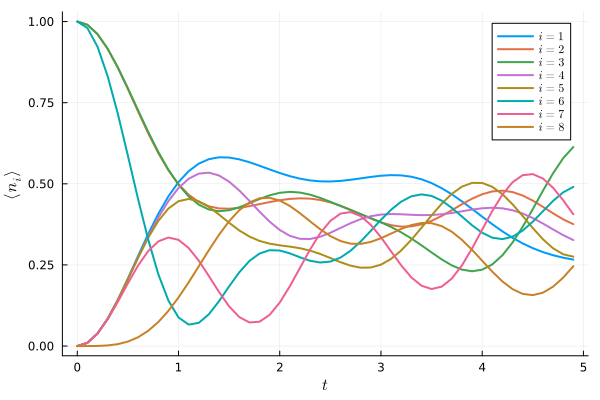

In [72]:
plot(ylabel = L"\langle n_{i} \rangle", xlabel = L"t")
for site = 1:N

    plot!(times, occupation_t[:,site], label = L"i = %$site", xlabel = L"t", linewidth = 2.0)
end
plot!()